# Demonstration of MUSE

This is a demonstration of MUSE analysis on a multi-modality simulated data.

Feng Bao @ Altschuler & Wu Lab @ UCSF 2022.

Software provided as is under MIT License.

## Import packages

In [1]:
import multi_muse_sc as muse
import simulation_tool.multi_modal_simulation as simulation

import phenograph
from sklearn.decomposition import PCA
import numpy as np
from sklearn.metrics.cluster import adjusted_rand_score
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
# import tensorflow as tf
# import os
# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
# tf.get_logger().setLevel('ERROR')
np.random.seed(0)

## Generate simulation data


Simulation parameters

In [2]:
latent_dim = 100
num_cluster = 10
sample_size = 1000
latent_code_dim = 30
observed_data_dim = 500
sigma_1 = 0.1  
sigma_2 = 0.1
decay_coef_1 = 0.5 
decay_coef_2 = 0.1
merge_prob = 0.7



Use simulation tool to generate multi-modality data

In [3]:
data = simulation.multi_modal_simulator(
    num_cluster,
    sample_size,
    observed_data_dim,
    observed_data_dim,
    latent_code_dim,
    sigma_1,
    sigma_2,
    decay_coef_1,
    decay_coef_2,
    merge_prob,
)
data_a = data["data_a_dropout"]
data_b = data["data_b_dropout"]
label_a = data["data_a_label"]
label_b = data["data_b_label"]
label_true = data["true_cluster"]

## Analyses based on single modality

Learn features from single modality

In [4]:
view_a_feature = PCA(n_components=latent_dim).fit_transform(data_a)
view_b_feature = PCA(n_components=latent_dim).fit_transform(data_b)

In [5]:
data_ab = data_a + data_b
view_ab_feature = PCA(n_components=latent_dim).fit_transform(data_ab)

In [6]:
print(f"data_a shape: {data_a.shape}")
print(f"data_b shape: {data_b.shape}")
print(f"view_a_feature shape: {view_a_feature.shape}")
print(f"view_b_feature shape: {view_b_feature.shape}")

data_a shape: (1000, 500)
data_b shape: (1000, 500)
view_a_feature shape: (1000, 100)
view_b_feature shape: (1000, 100)


Perform clustering using PhenoGraph

In [7]:
view_a_label, _, _ = phenograph.cluster(view_a_feature)
view_b_label, _, _ = phenograph.cluster(view_b_feature)
view_ab_label, _, _ = phenograph.cluster(view_ab_feature)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.06811857223510742 seconds
Jaccard graph constructed in 0.18482732772827148 seconds
Wrote graph to binary file in 0.00626826286315918 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.640279
Louvain completed 21 runs in 0.39549732208251953 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 0.7690422534942627 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.06948089599609375 seconds
Jaccard graph constructed in 0.13790321350097656 seconds
Wrote graph to binary file in 0.004744291305541992 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.742588
Louvain completed 21 runs in 0.3689689636230469 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 0.6918933391571045 seconds
Finding 30 nearest neighbors using minko

## Combined analysis using MUSE

MUSE learns the joint latent representation

In [8]:
outputs = muse.dual_muse_fit_predict(
    [data_a, data_b],
    [data_ab],
    [view_a_label, view_b_label],
    [view_ab_label],
    latent_dim=100,
    n_epochs=500,
    info_nce_lambda=1000,
    weight_penalty=5,
    triplet_lambda=5,
)

++++++++++ DualMUSE for multi-modality single-cell analysis ++++++++++
#epoch: 0/200 	 total loss: 8142.13 	 sc loss: 703.23 	 st loss: 506.12 	 infoNCE: 6932.77 	 sc recon: 0.04 	 st recon: 0.03 	 sc sparse: 703.19 	 st sparse: 506.09 	 sc trip: 0.00 	 st trip: 0.00
#epoch: 50/200 	 total loss: 8043.41 	 sc loss: 661.94 	 st loss: 477.00 	 infoNCE: 6904.48 	 sc recon: 0.01 	 st recon: 0.02 	 sc sparse: 661.93 	 st sparse: 476.99 	 sc trip: 0.00 	 st trip: 0.00
#epoch: 100/200 	 total loss: 7975.84 	 sc loss: 622.34 	 st loss: 449.08 	 infoNCE: 6904.42 	 sc recon: 0.01 	 st recon: 0.01 	 sc sparse: 622.33 	 st sparse: 449.06 	 sc trip: 0.00 	 st trip: 0.00
#epoch: 150/200 	 total loss: 7914.36 	 sc loss: 584.23 	 st loss: 422.19 	 infoNCE: 6907.94 	 sc recon: 0.01 	 st recon: 0.01 	 sc sparse: 584.22 	 st sparse: 422.18 	 sc trip: 0.00 	 st trip: 0.00
#epoch: 0/200 	 total loss: 7860.38 	 sc loss: 553.67 	 st loss: 399.56 	 infoNCE: 6907.15 	 sc recon: 0.01 	 st recon: 0.01 	 sc sparse

## Perform clustering
PhenoGraph clustering

In [9]:
latent_sc, latent_st = outputs[0], outputs[1]
muse_label_sc, _, _ = phenograph.cluster(latent_sc)
muse_label_st, _, _ = phenograph.cluster(latent_st)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.0671687126159668 seconds
Jaccard graph constructed in 0.25780630111694336 seconds
Wrote graph to binary file in 0.003911495208740234 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.897599
Louvain completed 21 runs in 0.8134775161743164 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 1.3955154418945312 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.06821537017822266 seconds
Jaccard graph constructed in 0.28728795051574707 seconds
Wrote graph to binary file in 0.004064321517944336 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.8613
Louvain completed 21 runs in 0.803978681564331 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 1.4014689922332764 seconds
Finding 30 nearest neighbors using minkowski

## Visualization of latent spaces 
Latent spaces of single-modality features or MUSE features were visualized using tSNE, with ground truth cluster labels.

Cluster accuries were quantified using adjusted Rand index (ARI). ARI = 1 indicates perfectly discover true cell identities.

view_a_feature: (1000, 100)
X_embedded: (1000, 2)
label_true: (1000,)
laber_true == i: (1000,)
np.nonzero(label_true == i): 105


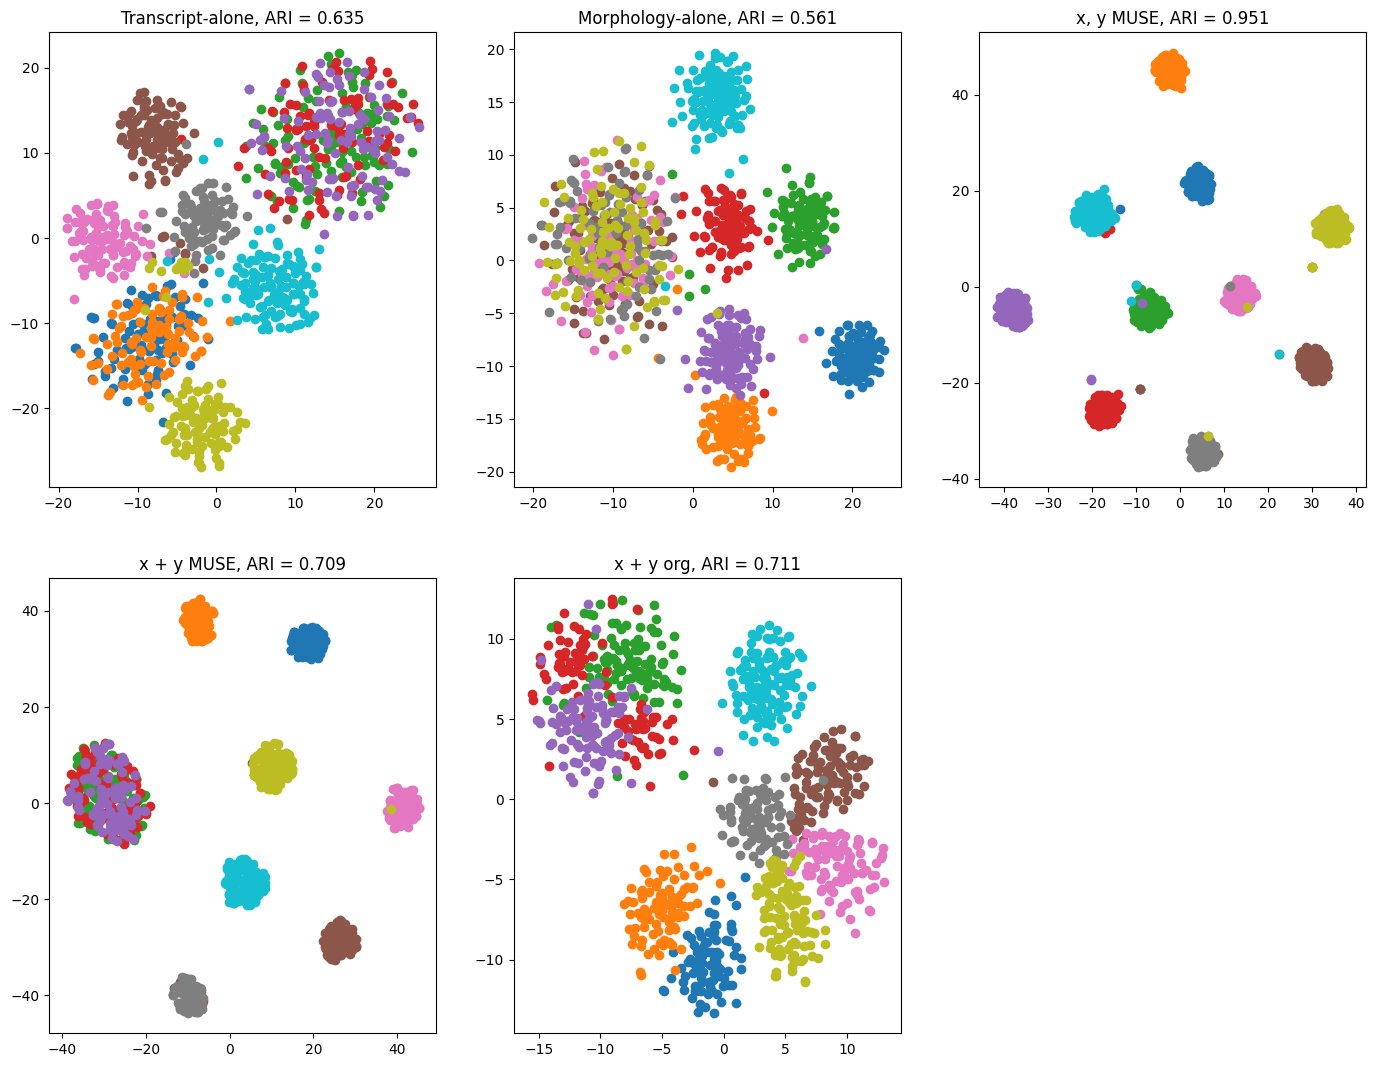

In [12]:
plt.figure(figsize=(17, 13))
plt.subplot(2, 3, 1)
print(f"view_a_feature: {view_a_feature.shape}")
X_embedded = TSNE(n_components=2).fit_transform(view_a_feature)
print(f"X_embedded: {X_embedded.shape}")
print(f"label_true: {label_true.shape}")
print(f"laber_true == i: {(label_true == 0).shape}")
print(f"np.nonzero(label_true == i): {len(np.nonzero(label_true == 2)[0])}")
# 遍历每一个类别
for i in np.unique(label_true):
    # 找到所有类别为i的索引
    idx = np.nonzero(label_true == i)[0]
    # 将类别为i的点画成散点图
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    # 设置标题
    plt.title('Transcript-alone, ARI = %01.3f' % adjusted_rand_score(label_true, view_a_label))

plt.subplot(2, 3, 2)
X_embedded = TSNE(n_components=2).fit_transform(view_b_feature)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('Morphology-alone, ARI = %01.3f' % adjusted_rand_score(label_true, view_b_label))

plt.subplot(2, 3, 3)
X_embedded = TSNE(n_components=2).fit_transform(latent_sc)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('x, y MUSE, ARI = %01.3f' % adjusted_rand_score(label_true, muse_label_sc))

plt.subplot(2, 3, 4)
X_embedded = TSNE(n_components=2).fit_transform(latent_st)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('x + y MUSE, ARI = %01.3f' % adjusted_rand_score(label_true, muse_label_st))

plt.subplot(2, 3, 5)
X_embedded = TSNE(n_components=2).fit_transform(data_ab)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('x + y org, ARI = %01.3f' % adjusted_rand_score(label_true, view_ab_label))

